# The Price of Coupling — playground

Rebuilds the headline figures of both parts from the raw files in this repo.
CPU-only, matplotlib + numpy, runs in well under a minute.

**Part I (OPBF):** a learned *proxy* objective for decomposing a loss into skills
lost to k-means, a generic encoder, and a random partition. **Part II (the reboot):**
training on the desideratum itself — independent-training-then-merge fidelity — died
at its pre-registered gate zero, and the repair round showed the objective family
contains no usable trace of the structure. The story is in [BLOG.md](BLOG.md);
Part II's full pre-registered research repo is vendored under [reboot/](reboot/).

In [1]:
import json, re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# --- data -------------------------------------------------------------------
e7 = json.loads(Path("data/e7_results.json").read_text())
e6 = json.loads(Path("data/e6_results.json").read_text())
e9 = json.loads(Path("data/e9_results.json").read_text())

# revalidation re-run of the hard-assignment probe (12 seeds, stdout log)
hard_log = Path("revalidation/probe_e7_hard_rerun.txt").read_text()
seed_rows = re.findall(r"seed (\d+): soft=([\d.]+)\s+hard=([\d.]+)\s+kmeans=([\d.]+)", hard_log)
soft_r, hard_r, km_r = (np.array([float(r[i]) for r in seed_rows]) for i in (1, 2, 3))

# --- style ------------------------------------------------------------------
SURFACE = "#fcfcfb"; INK = "#0b0b0b"; SECOND = "#52514e"; MUTED = "#898781"
GRID = "#e1e0d9"; BASE = "#c3c2b7"
BLUE = "#2a78d6"   # OPBF (the learned mechanism) — same entity, same hue, everywhere
ORANGE = "#eb6834" # the fair baseline that wins (named per figure)
AQUA = "#1baf7a"   # third series (scratch / hard variant)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASE, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.labelcolor": SECOND, "axes.titlecolor": INK,
    "font.family": "sans-serif", "font.size": 11,
    "figure.dpi": 110,
})
print(f"loaded: e7 ({e7['results']['config']['n_seeds']} seeds), "
      f"e6 ({e6['results']['config']['n_seeds']} seeds), "
      f"e9 ({e9['results']['config']['n_seeds']} seeds), "
      f"hard-probe rerun ({len(seed_rows)} seeds)")

loaded: e7 (10 seeds), e6 (20 seeds), e9 (5 seeds), hard-probe rerun (12 seeds)


## 1 · The scoreboard

Four head-to-head kills, one panel each: the learned OPBF mechanism (blue) against the
dumbest fair opponent that beats it (orange). Both sides always get the same signal,
data, and budget — fairness was audited at code level and re-run during revalidation.

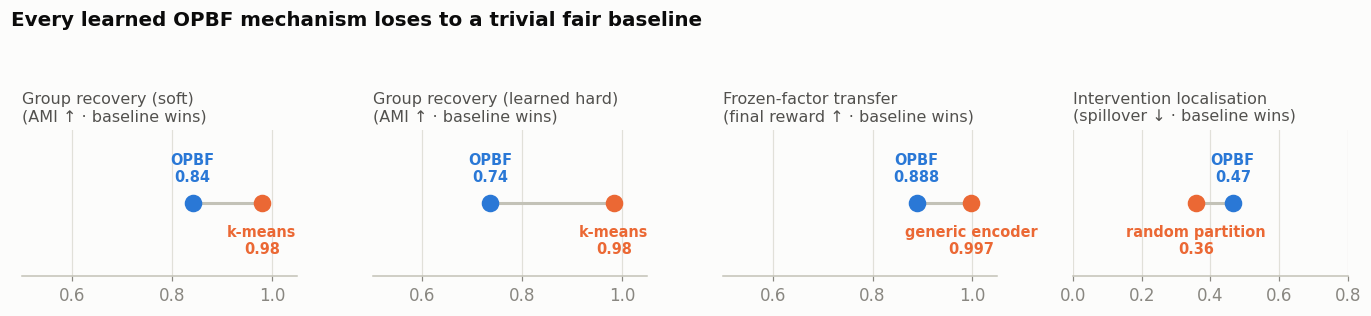

In [2]:
panels = [
    # title, opponent name, opbf value, baseline value, xlim, higher_better
    ("Group recovery (soft)", "k-means",
     e7["gate"]["ami_mean"], e7["gate"]["kmeans_ami_mean"], (0.5, 1.05), True),
    ("Group recovery (learned hard)", "k-means",
     hard_r.mean(), km_r.mean(), (0.5, 1.05), True),
    ("Frozen-factor transfer", "generic encoder",
     e6["gate"]["mean_asymptote"]["opbf_transfer"],
     e6["gate"]["mean_asymptote"]["sf_fair"], (0.5, 1.05), True),
    ("Intervention localisation", "random partition",
     e9["gate"]["separable"]["spillover_mean"],
     e9["gate"]["separable"]["rand_spillover_mean"], (0.0, 0.8), False),
]
units = ["AMI \u2191", "AMI \u2191", "final reward \u2191", "spillover \u2193"]
fmts = [".2f", ".2f", ".3f", ".2f"]

fig, axes = plt.subplots(1, 4, figsize=(12.5, 2.9))
fig.suptitle("Every learned OPBF mechanism loses to a trivial fair baseline",
             x=0.005, ha="left", fontsize=13, fontweight="bold")
for ax, (title, opp, v_opbf, v_base, xlim, hi), unit, fmt in zip(axes, panels, units, fmts):
    y = 0
    ax.plot([v_opbf, v_base], [y, y], color=BASE, lw=2, zorder=1)
    ax.scatter([v_opbf], [y], s=110, color=BLUE, zorder=3)
    ax.scatter([v_base], [y], s=110, color=ORANGE, zorder=3)
    ax.annotate(f"OPBF\n{v_opbf:{fmt}}", (v_opbf, y), textcoords="offset points",
                xytext=(0, 12), ha="center", va="bottom", fontsize=9.5, color=BLUE, fontweight="bold")
    ax.annotate(f"{opp}\n{v_base:{fmt}}", (v_base, y), textcoords="offset points",
                xytext=(0, -14), ha="center", va="top", fontsize=9.5, color=ORANGE, fontweight="bold")
    win = "baseline wins" if (v_base > v_opbf) == hi else "OPBF wins"
    ax.set_title(f"{title}\n({unit} \u00b7 {win})", fontsize=10.5, loc="left", color=SECOND)
    ax.set_xlim(*xlim); ax.set_ylim(-1.15, 1.15)
    ax.set_yticks([]); ax.grid(axis="y", visible=False)
    ax.spines["left"].set_visible(False)
fig.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()

In all four panels the baseline consumed **the same signal** as the factoriser:
k-means clusters the identical gradient-affinity matrix, the generic encoder gets the
identical pretraining data/steps/parameter count (1,092 each), and the random partition
gets nothing at all — it wins anyway.

## 2 · Recovery, per seed — the shape of the failure

Per-seed AMI from the revalidation re-run of the project's own hard-assignment probe
(12 seeds; matches the reported numbers to 0.004). The learned factoriser's failure is
**bimodal** — it either solves the task or collapses to ~0.6 — while k-means is perfect
on 11 of 12 seeds, including every seed where the learned mechanism collapses.

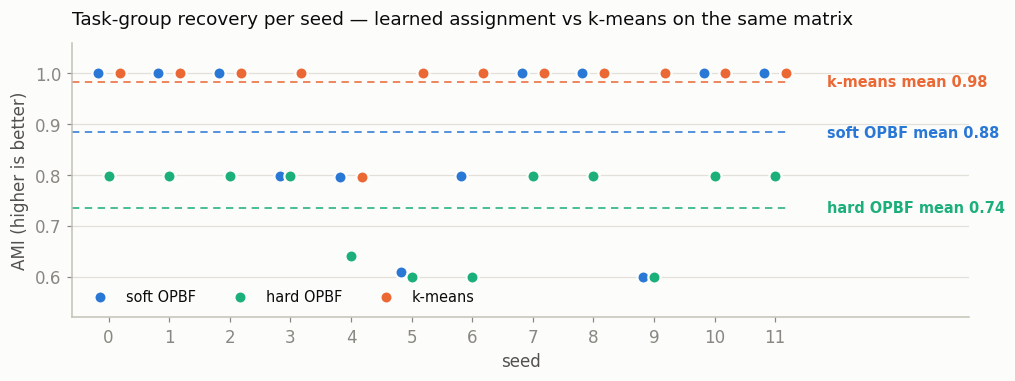

In [3]:
seeds = np.arange(len(soft_r))
fig, ax = plt.subplots(figsize=(9.5, 3.6))
for arr, col, name, dx in ((soft_r, BLUE, "soft OPBF", -0.18),
                           (hard_r, AQUA, "hard OPBF", 0.0),
                           (km_r, ORANGE, "k-means", 0.18)):
    ax.scatter(seeds + dx, arr, s=64, color=col, label=name, zorder=3,
               edgecolors=SURFACE, linewidths=1.5)
    ax.axhline(arr.mean(), xmax=0.80, color=col, lw=1.2, ls=(0, (4, 3)), alpha=0.85, zorder=2)
    ax.annotate(f"{name} mean {arr.mean():.2f}", (len(seeds) - 0.35, arr.mean()),
                xytext=(8, 0), textcoords="offset points", va="center",
                fontsize=9.5, color=col, fontweight="bold")
ax.set_title("Task-group recovery per seed — learned assignment vs k-means on the same matrix",
             loc="left", fontsize=12, pad=12)
ax.set_xlabel("seed"); ax.set_ylabel("AMI (higher is better)")
ax.set_xticks(seeds); ax.set_xlim(-0.6, len(seeds) + 2.2); ax.set_ylim(0.52, 1.06)
ax.grid(axis="x", visible=False)
ax.legend(loc="lower left", frameon=False, ncols=3, fontsize=9.5)
fig.tight_layout(); plt.show()

## 3 · Transfer — the learning curves

Mean learning curves on a held-out task (20 seeds): normalised reward vs online samples.
The frozen generic encoder (orange) is at the oracle ceiling almost immediately; frozen
OPBF factors (blue) climb fast *when recovery worked* but the mean is dragged by the
~30% of seeds where the grouping never recovered — a failure tail scratch training
(aqua) shares.

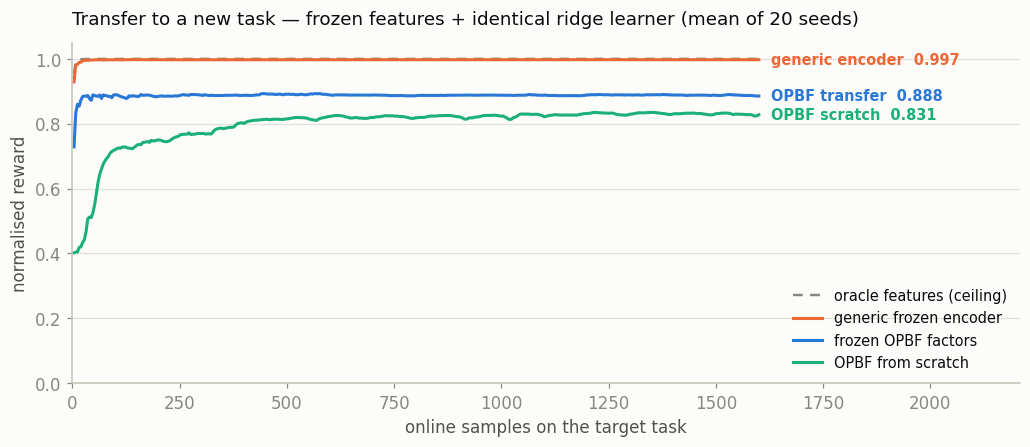

In [4]:
curves = e6["results"]["mean_curves"]
lb = e6["results"]["config"]["learn_batch"]
x = np.arange(1, len(curves["sf_fair"]) + 1) * lb
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(x, curves["sf_oracle"], color=MUTED, lw=1.6, ls=(0, (4, 3)), label="oracle features (ceiling)")
ax.plot(x, curves["sf_fair"], color=ORANGE, lw=2, label="generic frozen encoder")
ax.plot(x, curves["opbf_transfer"], color=BLUE, lw=2, label="frozen OPBF factors")
ax.plot(x, curves["opbf_scratch"], color=AQUA, lw=2, label="OPBF from scratch")
for key, col, name in (("sf_fair", ORANGE, "generic encoder  0.997"),
                       ("opbf_transfer", BLUE, "OPBF transfer  0.888"),
                       ("opbf_scratch", AQUA, "OPBF scratch  0.831")):
    ax.annotate(name, (x[-1], curves[key][-1]), xytext=(8, 0), textcoords="offset points",
                va="center", fontsize=9.5, color=col, fontweight="bold")
ax.set_title("Transfer to a new task — frozen features + identical ridge learner (mean of 20 seeds)",
             loc="left", fontsize=12, pad=12)
ax.set_xlabel("online samples on the target task"); ax.set_ylabel("normalised reward")
ax.set_xlim(0, x[-1] * 1.38); ax.set_ylim(0, 1.05)
ax.grid(axis="x", visible=False)
ax.legend(loc="lower right", frameon=False, fontsize=9.5)
fig.tight_layout(); plt.show()

## 4 · Interpretability — worse than random

Do-style intervention spillover (share of an intervention's effect that leaks into the
*wrong* factors; lower is better, pre-registered gate ≤ 0.2). The learned decomposition
not only misses the gate — it is **less localised than a random hard partition**, on
both the easy (separable) and hard (coupled) objectives. The hand-grouped oracle shows
the metric itself is sound.

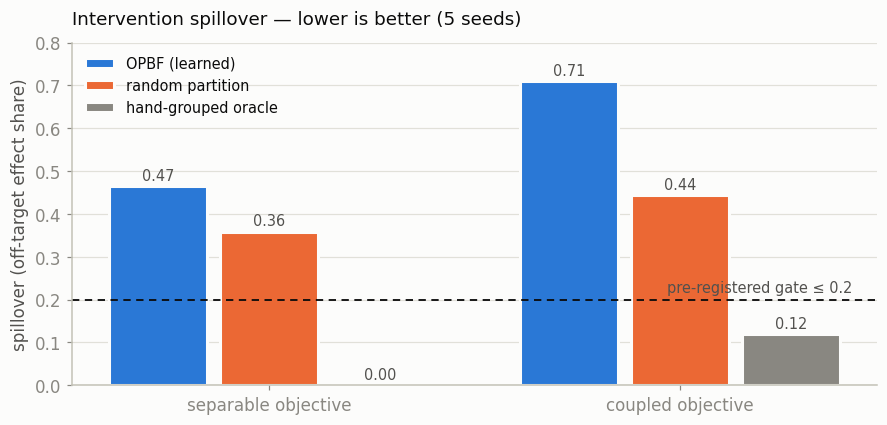

In [5]:
groups = ["separable", "coupled"]
series = [("OPBF (learned)", BLUE, "spillover_mean"),
          ("random partition", ORANGE, "rand_spillover_mean"),
          ("hand-grouped oracle", MUTED, "hg_spillover_mean")]
xg = np.arange(len(groups)); w = 0.24
fig, ax = plt.subplots(figsize=(8.2, 4.0))
for i, (name, col, key) in enumerate(series):
    vals = [e9["gate"][g][key] for g in groups]
    bars = ax.bar(xg + (i - 1) * (w + 0.03), vals, width=w, color=col, label=name,
                  edgecolor=SURFACE, linewidth=2)
    for b, v in zip(bars, vals):
        ax.annotate(f"{v:.2f}", (b.get_x() + b.get_width() / 2, v), xytext=(0, 4),
                    textcoords="offset points", ha="center", fontsize=9.5, color=SECOND)
ax.axhline(0.2, color=INK, lw=1.2, ls=(0, (4, 3)))
ax.annotate("pre-registered gate \u2264 0.2", (1.42, 0.2), xytext=(0, 5),
            textcoords="offset points", fontsize=9.5, color=SECOND, ha="right")
ax.set_title("Intervention spillover — lower is better (5 seeds)", loc="left", fontsize=12, pad=12)
ax.set_xticks(xg, [f"{g} objective" for g in groups])
ax.set_ylabel("spillover (off-target effect share)"); ax.set_ylim(0, 0.8)
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left", frameon=False, fontsize=9.5)
fig.tight_layout(); plt.show()

## 5 · The numbers, verbatim

Every value above, read straight from the raw files — plus the pre-registered gate
booleans the experiments were judged by.

In [6]:
hard_ci = 1.96 * hard_r.std(ddof=1) / len(hard_r) ** 0.5
km_ci = 1.96 * km_r.std(ddof=1) / len(km_r) ** 0.5
n_fail = sum(a < 0.9 for a in e6["results"]["asymptote"]["opbf_transfer"])
rows = [
    ("E7 recovery: OPBF soft AMI",     f"{e7['gate']['ami_mean']:.3f}",                 "data/e7_results.json"),
    ("E7 recovery: k-means AMI",       f"{e7['gate']['kmeans_ami_mean']:.3f}",          "data/e7_results.json"),
    ("E7 gate passed",                 str(e7["gate"]["passed"]),                        "data/e7_results.json"),
    ("(c) hard-OPBF AMI (rerun)",      f"{hard_r.mean():.3f} \u00b1 {hard_ci:.3f}",     "revalidation/probe_e7_hard_rerun.txt"),
    ("(c) k-means AMI (rerun)",        f"{km_r.mean():.3f} \u00b1 {km_ci:.3f}",         "revalidation/probe_e7_hard_rerun.txt"),
    ("E6 transfer: OPBF asymptote",    f"{e6['gate']['mean_asymptote']['opbf_transfer']:.3f}", "data/e6_results.json"),
    ("E6 transfer: generic encoder",   f"{e6['gate']['mean_asymptote']['sf_fair']:.3f}", "data/e6_results.json"),
    ("E6 transfer: oracle ceiling",    f"{e6['gate']['mean_asymptote']['sf_oracle']:.3f}", "data/e6_results.json"),
    ("E6 seeds never reaching 0.9",    f"{n_fail}/20",                                   "data/e6_results.json"),
    ("E6 gate passed",                 str(e6["gate"]["passed"]),                        "data/e6_results.json"),
    ("E9 spillover sep/coup (OPBF)",   f"{e9['gate']['separable']['spillover_mean']:.2f} / {e9['gate']['coupled']['spillover_mean']:.2f}", "data/e9_results.json"),
    ("E9 spillover sep/coup (random)", f"{e9['gate']['separable']['rand_spillover_mean']:.2f} / {e9['gate']['coupled']['rand_spillover_mean']:.2f}", "data/e9_results.json"),
    ("E9 OPBF beats random",           str(e9["gate"]["separable"]["opbf_beats_random_spillover"]), "data/e9_results.json"),
]
wname = max(len(r[0]) for r in rows); wval = max(len(r[1]) for r in rows)
print(f"{'metric':<{wname}}  {'value':<{wval}}  source")
print("-" * (wname + wval + 40))
for name, val, src in rows:
    print(f"{name:<{wname}}  {val:<{wval}}  {src}")

metric                          value          source
-----------------------------------------------------------------------------------
E7 recovery: OPBF soft AMI      0.841          data/e7_results.json
E7 recovery: k-means AMI        0.980          data/e7_results.json
E7 gate passed                  False          data/e7_results.json
(c) hard-OPBF AMI (rerun)       0.735 ± 0.053  revalidation/probe_e7_hard_rerun.txt
(c) k-means AMI (rerun)         0.983 ± 0.033  revalidation/probe_e7_hard_rerun.txt
E6 transfer: OPBF asymptote     0.888          data/e6_results.json
E6 transfer: generic encoder    0.997          data/e6_results.json
E6 transfer: oracle ceiling     1.000          data/e6_results.json
E6 seeds never reaching 0.9     6/20           data/e6_results.json
E6 gate passed                  False          data/e6_results.json
E9 spillover sep/coup (OPBF)    0.47 / 0.71    data/e9_results.json
E9 spillover sep/coup (random)  0.36 / 0.44    data/e9_results.json
E9 OPBF beats 

---
# Part II — gate zero and the repair round

Raw gate results from [`reboot/results/`](reboot/results/): Z2 (warm-start at the
truth, full outer optimisation), the optimizer-free landscape diagnostic that proves
the kill is the objective's preference rather than optimiser noise, and the R1
calibration sweep under the artifact-corrected merge.

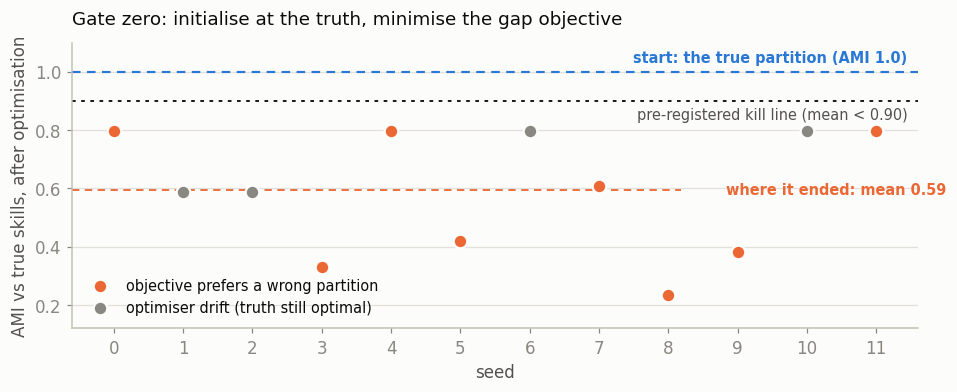

landscape diagnostic: truth is NOT a local optimum on 8/12 seeds (update-sum merge)


In [7]:
z2 = json.loads(Path("reboot/results/z2.json").read_text())
diag = json.loads(Path("reboot/results/diag_z2.json").read_text())
r1 = json.loads(Path("reboot/results/r1_calib.json").read_text())
amis2 = z2["amis"]
cls = [("OBJECTIVE" in r["classification"]) for r in diag["per_seed"]]
seeds2 = np.arange(len(amis2))

fig, ax = plt.subplots(figsize=(9.0, 3.7))
for obj, col, name in ((True, ORANGE, "objective prefers a wrong partition"),
                       (False, MUTED, "optimiser drift (truth still optimal)")):
    idx = [i for i in seeds2 if cls[i] == obj]
    ax.scatter(idx, [amis2[i] for i in idx], s=80, color=col, label=name, zorder=3,
               edgecolors=SURFACE, linewidths=1.5)
ax.axhline(1.0, color=BLUE, lw=1.4, ls=(0, (4, 3)))
ax.annotate("start: the true partition (AMI 1.0)", (11.45, 1.0), xytext=(0, 6),
            textcoords="offset points", ha="right", fontsize=9.5, color=BLUE, fontweight="bold")
ax.axhline(0.90, color=INK, lw=1.2, ls=(0, (2, 3)))
ax.annotate("pre-registered kill line (mean < 0.90)", (11.45, 0.90), xytext=(0, -12),
            textcoords="offset points", ha="right", fontsize=9.5, color=SECOND)
m2 = float(np.mean(amis2))
ax.axhline(m2, color=ORANGE, lw=1.2, ls=(0, (4, 3)), xmax=0.72)
ax.annotate(f"where it ended: mean {m2:.2f}", (8.7, m2), xytext=(6, 0),
            textcoords="offset points", va="center", fontsize=9.5, color=ORANGE,
            fontweight="bold")
ax.set_title("Gate zero: initialise at the truth, minimise the gap objective",
             loc="left", fontsize=12, pad=12)
ax.set_xlabel("seed"); ax.set_ylabel("AMI vs true skills, after optimisation")
ax.set_xticks(seeds2); ax.set_ylim(0.12, 1.10); ax.set_xlim(-0.6, 11.6)
ax.grid(axis="x", visible=False)
ax.legend(loc="lower left", frameon=False, fontsize=9.5)
fig.tight_layout(); plt.show()
print(f"landscape diagnostic: truth is NOT a local optimum on "
      f"{diag['n_objective_prefers_wrong']}/12 seeds (update-sum merge)")

The repair round (R1): damped update-sum with per-evaluation line search, swept over
the full (K × lr) grid. With the overshoot artifact removed, true and random
partitions are statistically indistinguishable in every cell — and the
uniform-copies family is frequently the best partition in the grid.

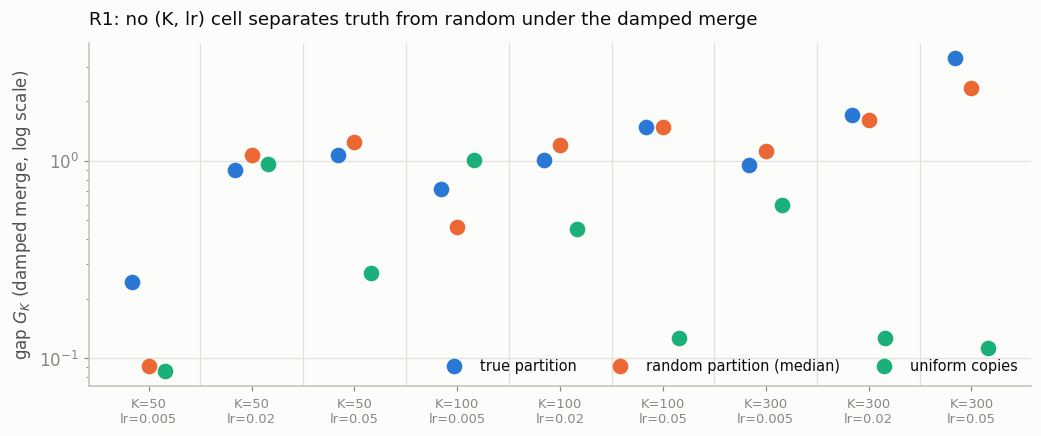

separation criterion (needs ratio >= 3):
  K50_lr0.005: sep=False (ratio -1.2)
  K50_lr0.02: sep=False (ratio 0.5)
  K50_lr0.05: sep=False (ratio 0.4)
  K100_lr0.005: sep=False (ratio -0.8)
  K100_lr0.02: sep=False (ratio 0.5)
  K100_lr0.05: sep=False (ratio 0.0)
  K300_lr0.005: sep=False (ratio 0.5)
  K300_lr0.02: sep=False (ratio -0.1)
  K300_lr0.05: sep=False (ratio -0.8)


[None, None, None, None, None, None, None, None, None]

In [8]:
cells = r1["cells"]
keys = [f"K{K}_lr{lr}" for K in (50, 100, 300) for lr in (0.005, 0.02, 0.05)]
labels = [k.replace("K", "K=").replace("_lr", chr(10) + "lr=") for k in keys]
x = np.arange(len(keys))
tr = [cells[k]["G_true_mean"] for k in keys]
rd = [cells[k]["G_random_median"] for k in keys]
un = [cells[k]["G_uniform_mean"] for k in keys]

fig, ax = plt.subplots(figsize=(9.6, 4.1))
ax.scatter(x - 0.16, tr, s=85, color=BLUE, label="true partition", zorder=3)
ax.scatter(x, rd, s=85, color=ORANGE, label="random partition (median)", zorder=3)
ax.scatter(x + 0.16, un, s=85, color=AQUA, label="uniform copies", zorder=3)
for xi in x[:-1]:
    ax.axvline(xi + 0.5, color=GRID, lw=0.8)
ax.set_yscale("log")
ax.set_title("R1: no (K, lr) cell separates truth from random under the damped merge",
             loc="left", fontsize=12, pad=12)
ax.set_xticks(x, labels, fontsize=8.5)
ax.set_ylabel("gap $G_K$ (damped merge, log scale)")
ax.grid(axis="x", visible=False)
ax.legend(loc="lower right", frameon=False, fontsize=9.5, ncols=3)
fig.tight_layout(); plt.show()
seps = [f"{k}: sep={cells[k]['separated']} (ratio {cells[k]['sep_ratio']:.1f})" for k in keys]
print("separation criterion (needs ratio >= 3):"); [print(" ", s) for s in seps]

---

The one-line verdict across both parts: the cheap objectives that seem to point at
decomposition do not have it as their minimum — the proxy points elsewhere (Part I),
and the desideratum's operational surrogate is dominated by merge-operator physics,
with nothing underneath once the physics is subtracted (Part II). The idealised
equality at exact minimisation remains untested — and undescendable, which is the
open question. Full gate trail: [reboot/DESIGN-DRAFT.md](reboot/DESIGN-DRAFT.md) and
[reboot/VERDICT-STAGE1.md](reboot/VERDICT-STAGE1.md).